In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from process_data import process_data, window_normalize_FE
from pathlib import Path

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

In [3]:
from DeepLOB import create_dataloader, FE_DeepLOB, train_model, validate_engine, PnLFocalLoss, EarlyStopping

In [4]:
# Define Hyperparameter
alpha = 0.5 * 1e-4  #bps
FE = True
label_window = 10   #ticks
window_size = 100  #ticks
normalize_window = 5 #days

In [ ]:
inputpath = 'Data/Raw_data/'
outputpath = 'Data/FE_DeepLOB_data/Processed_data/'
path = Path(outputpath)
path.mkdir(parents=True, exist_ok=True)

raw_files = list(Path(inputpath).glob('*.csv'))

for raw_file in raw_files:
    print(f'Processing file:{raw_file.name}')
    outputfile = f'{outputpath}processed_{raw_file.stem[-4:]}.csv'
    process_data(raw_file, outputfile, label_method='l2', label_window = label_window, FE = FE, alpha = alpha)

inputpath_normalized = 'Data/FE_DeepLOB_data/Processed_data/'
outputpath_normalized = 'Data/FE_DeepLOB_data/Normalized_data/' 
path = Path(outputpath_normalized)
path.mkdir(parents=True, exist_ok=True)
window_normalize_FE(inputpath_normalized, outputpath_normalized, window_size = normalize_window)

Processing file:IM2606_20260401.csv
Data processing completed. Processed data saved to Data/FE_DeepLOB_data/Processed_data/processed_0401.csv.
Processing file:IM2606_20260402.csv
Data processing completed. Processed data saved to Data/FE_DeepLOB_data/Processed_data/processed_0402.csv.
Processing file:IM2606_20260403.csv
Data processing completed. Processed data saved to Data/FE_DeepLOB_data/Processed_data/processed_0403.csv.
Processing file:IM2606_20260407.csv
Data processing completed. Processed data saved to Data/FE_DeepLOB_data/Processed_data/processed_0407.csv.
Processing file:IM2606_20260408.csv
Data processing completed. Processed data saved to Data/FE_DeepLOB_data/Processed_data/processed_0408.csv.
Processing file:IM2606_20260409.csv
Data processing completed. Processed data saved to Data/FE_DeepLOB_data/Processed_data/processed_0409.csv.
Processing file:IM2606_20260410.csv
Data processing completed. Processed data saved to Data/FE_DeepLOB_data/Processed_data/processed_0410.csv.

## Benchmark regression

In [17]:
from DeepLOB import create_dataloader

inputpath = 'Data/Normalized_data_6F/'

train_loader, label_train = create_dataloader(inputpath, start_files=0, num_files=20, window_size=100, target_size=1, batch_size=32, shuffle=True)

val_loader, label_val = create_dataloader(inputpath, start_files=20, num_files=4, window_size=100, target_size=1, batch_size=32, shuffle=False)

Found 20 CSV files for this dataloader.

Total days used for training: 20
Total samples in final dataset: 558251

Sample X shape: torch.Size([100, 6]), Sample Y shape: torch.Size([1])

Batch Size: 32
Total number of batches per epoch: 17445

Data shape: torch.Size([32, 100, 6])
Label shape: torch.Size([32, 1])

Label distribution across all training files:
          Count
Down     139037
Neutral  279209
Up       141985
Found 4 CSV files for this dataloader.

Total days used for training: 4
Total samples in final dataset: 113606

Sample X shape: torch.Size([100, 6]), Sample Y shape: torch.Size([1])

Batch Size: 32
Total number of batches per epoch: 3550

Data shape: torch.Size([32, 100, 6])
Label shape: torch.Size([32, 1])

Label distribution across all training files:
         Count
Down     33617
Neutral  46556
Up       33829


In [18]:
X_all = []
y_all = []

for batch_x, batch_y in train_loader:
    batch_x_flat = batch_x.view(batch_x.size(0), -1)
    X_all.append(batch_x_flat.numpy())
    y_all.append(batch_y.numpy())

X_train = np.concatenate(X_all, axis = 0)
y_train = np.concatenate(y_all, axis = 0)
X_train.shape

(558240, 600)

In [19]:
X_all = []
y_all = []


total_batches = len(train_loader)
target_batches = int(total_batches * 0.1) 

print(f"总共有 {total_batches} 个批次，正在抽取前 {target_batches} 个批次...")

# 2. 带有计数功能的循环
for i, (batch_x, batch_y) in enumerate(train_loader):
    # 达到目标批次后停止
    if i >= target_batches:
        break
        
    batch_x_flat = batch_x.view(batch_x.size(0), -1)
    X_all.append(batch_x_flat.numpy())
    y_all.append(batch_y.numpy())

# 3. 合并数据
X_train = np.concatenate(X_all, axis=0)
y_train = np.concatenate(y_all, axis=0)

print(f"处理完成，X_train 形状: {X_train.shape}")


总共有 17445 个批次，正在抽取前 1744 个批次...
处理完成，X_train 形状: (55808, 600)


In [20]:
from sklearn.linear_model import RidgeClassifier
model = RidgeClassifier(alpha=1.0)
model.fit(X_train, y_train)

/root/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:1332: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/root/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.364029469021261e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,"alpha alpha: float, default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If set to false, nointercept will be used in calculations (e.g. data is expected to bealready centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.The default value is determined by scipy.sparse.linalg.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard scipy.linalg.solve function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in scipy.sparse.linalg.cg. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine scipy.sparse.linalg.lsqr. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its unbiased and more flexible version named SAGA. Both methods use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from sklearn.preprocessing. .. versionadded:: 0.17 Stochastic Average Gradient descent solver. .. versionadded:: 0.19 SAGA solver.- 'lbfgs' uses L-BFGS-B algorithm implemented in `scipy.optimize.minimize`. It can be used only when `positive` is True.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details.",None


In [21]:
X_all = []
y_all = []
for batch_x, batch_y in val_loader:
    batch_x_flat = batch_x.view(batch_x.size(0), -1)
    X_all.append(batch_x_flat.numpy())
    y_all.append(batch_y.numpy())

X_val = np.concatenate(X_all, axis = 0)
y_val = np.concatenate(y_all, axis = 0)
X_val.shape

(113600, 600)

In [22]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.00      0.00     33463
           1       0.41      1.00      0.58     46499
           2       0.47      0.00      0.00     33638

    accuracy                           0.41    113600
   macro avg       0.46      0.33      0.19    113600
weighted avg       0.45      0.41      0.24    113600



In [23]:
def tf_dataset_to_lgbm_df(dataset):
    x_list = []
    y_list = []
    
    for x_batch, y_batch in dataset:
        x_list.append(x_batch.numpy())
        y_list.append(y_batch.numpy())
    
    X = np.concatenate(x_list, axis=0) 
    y = np.concatenate(y_list, axis=0)
    
    N, T, F = X.shape
    X_flat = X.reshape(N, T * F)
    
    feature_names = [f'F{f}_T{t}' for t in range(T) for f in range(F)]
    
    df = pd.DataFrame(X_flat, columns=feature_names)
    return df, y

In [24]:
X_train, y_train = tf_dataset_to_lgbm_df(train_loader)
X_val, y_val = tf_dataset_to_lgbm_df(val_loader)

KeyboardInterrupt: 

In [28]:
import lightgbm as lgb
trian_data = lgb.Dataset(X_train, label = y_train)
val_data = lgb.Dataset(X_val, label = y_val)

params = {
    'objective':'multiclass',
    'num_class':3,
    'metric':'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

model = lgb.train(params, trian_data, num_boost_round=500, valid_sets=[val_data], callbacks=[lgb.early_stopping(stopping_rounds=20)])

c:\Users\mvt00\anaconda3\envs\py_311\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
c:\Users\mvt00\anaconda3\envs\py_311\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")


KeyboardInterrupt: 

In [ ]:
y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis = 1)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.73      0.85      0.79     12028
         1.0       0.00      0.00      0.00      4275
         2.0       0.72      0.86      0.79     12241

    accuracy                           0.73     28544
   macro avg       0.49      0.57      0.52     28544
weighted avg       0.62      0.73      0.67     28544



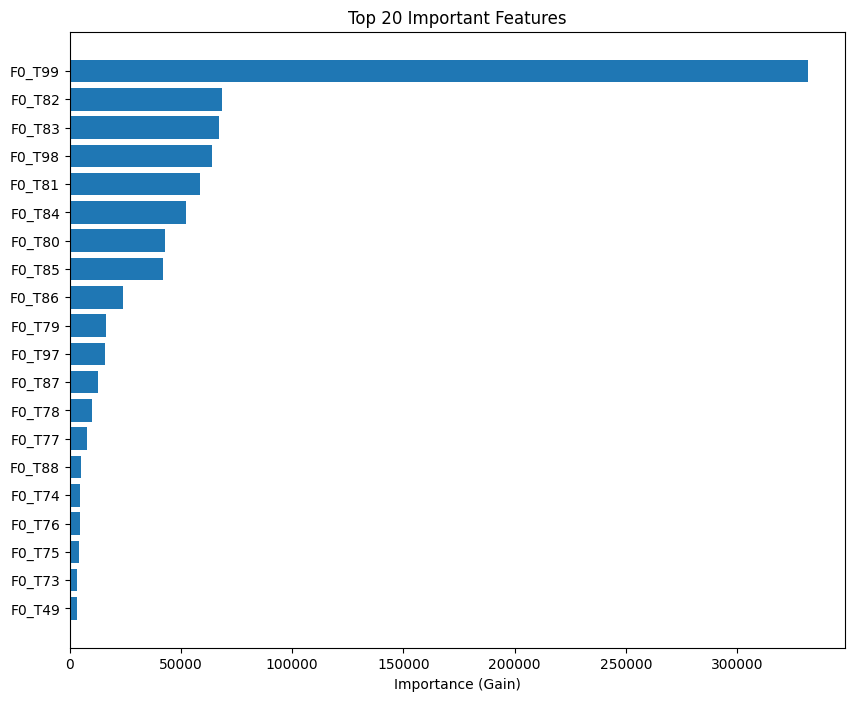

In [ ]:
import matplotlib.pyplot as plt

# 1. 提取重要性数据 (返回的是一个数组，顺序与你的列名一致)
importances = model.feature_importance(importance_type='gain') # 或者 'split'

# 2. 将重要性与对应的特征名关联起来
feature_names = X_train.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

# 3. 按重要性降序排列
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 4. 可视化前 20 个最重要的特征
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'].head(20), importance_df['importance'].head(20))
plt.gca().invert_yaxis() # 让最重要的特征排在最上面
plt.xlabel('Importance (Gain)')
plt.title('Top 20 Important Features')
plt.show()

## DeepLOB

In [8]:
inputpath = 'Data/FE_DeepLOB_data/Normalized_data'

train_loader, label_train = create_dataloader(inputpath, start_files=0, num_files=24, window_size=window_size, target_size=1, batch_size=512, shuffle=True)

val_loader, label_val = create_dataloader(inputpath, start_files = 24, num_files=4, window_size=window_size, target_size=1, batch_size=64, shuffle=False, drop_last=False)

test_loader, label_test = create_dataloader(inputpath, start_files=28, num_files=3, window_size=window_size, target_size=1, batch_size=32, shuffle=False, drop_last = False)

Found 24 CSV files for this dataloader.

Total days used for training: 24
Total samples in final dataset: 671857

Sample X shape: torch.Size([100, 6]), Sample Y shape: torch.Size([1])

Batch Size: 512
Total number of batches per epoch: 1312

Data shape: torch.Size([512, 100, 6])
Label shape: torch.Size([512, 1])

Label distribution across all training files:
          Count
Down     194940
Neutral  280737
Up       198556
Found 4 CSV files for this dataloader.

Total days used for training: 4
Total samples in final dataset: 114079

Sample X shape: torch.Size([100, 6]), Sample Y shape: torch.Size([1])

Batch Size: 64
Total number of batches per epoch: 1783

Data shape: torch.Size([64, 100, 6])
Label shape: torch.Size([64, 1])

Label distribution across all training files:
         Count
Down     40537
Neutral  33026
Up       40912
Found 3 CSV files for this dataloader.

Total days used for training: 3
Total samples in final dataset: 85611

Sample X shape: torch.Size([100, 6]), Sample Y s

In [ ]:
# Define training parameter
num_features = 5
num_epochs = 200

learning_rate = 0.0005

total_steps = len(train_loader) * num_epochs
warmup_steps = int(total_steps * 0.05)

class_weights = label_train['Count'].sum() / (label_train['Count'] * len(label_train))
weights = torch.tensor(class_weights.values, dtype=torch.float32)
print(f"\nClass weights for CrossEntropyLoss:{weights}")

pnl_matrix = [
    [0.90, 0.10, 0.00],
    [0.15, 0.70, 0.15],
    [0.00, 0.10, 0.90]
]

In [ ]:
loss_history = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

FE_DeepLOB_model = FE_DeepLOB(num_features=num_features, num_classes=3)
FE_DeepLOB_model.to(device)

optimizer = torch.optim.AdamW(FE_DeepLOB_model.parameters(), lr=learning_rate, weight_decay=1e-3)

lr_scheduler = SequentialLR(
    optimizer,
    schedulers=[
        LinearLR(optimizer, start_factor=0.01, total_iters=warmup_steps),
        CosineAnnealingLR(optimizer, T_max = total_steps - warmup_steps, eta_min=5e-5)
    ],
    milestones = [warmup_steps]
)

criterion = PnLFocalLoss(soft_targets=pnl_matrix, gamma=2.0, reduction='mean', device = device)

early_stopping = EarlyStopping(patience = 20, verbose = True, path = 'Model/cache_/deeplob_best_weights.pth', monitor_loss = True)

In [ ]:
print('Start training...')

for epoch in range(num_epochs):
    avg_loss, avg_acc = train_model(FE_DeepLOB_model, train_loader, optimizer, criterion, device, lr_scheduler = lr_scheduler)
    loss_history.append(avg_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}, Average Accuracy: {avg_acc:.4f}')

    avg_val_loss, avg_val_accuracy, _, _ = validate_engine(FE_DeepLOB_model, val_loader, criterion, device)
    early_stopping(avg_val_loss, FE_DeepLOB_model)

    if early_stopping.early_stop:
        print("Early stopping triggered. Training isolated.")
        break
print('Training Ends')
FE_DeepLOB_model.load_state_dict(torch.load('Model/cache_/deeplob_best_weights.pth', weights_only=True))
print("Best model weights loaded.")
FE_DeepLOB_model.eval()


Class weights for CrossEntropyLoss:tensor([0.9797, 1.0693, 0.9578])
Start training...


Training: 100%|██████████| 1311/1311 [00:45<00:00, 28.69batch/s, loss=1.1008, acc=31.65%, lr=0.000055]


Epoch 1/200, Average Loss: 1.1008, Average Accuracy: 31.6546
Validation Loss improved (inf --> 1.0974736401768364). Saving model ...


Training: 100%|██████████| 1311/1311 [00:35<00:00, 36.95batch/s, loss=1.0949, acc=35.15%, lr=0.000104]


Epoch 2/200, Average Loss: 1.0949, Average Accuracy: 35.1539
Validation Loss improved (1.097474 --> 1.068634125270715). Saving model ...


Training: 100%|██████████| 1311/1311 [00:40<00:00, 32.54batch/s, loss=1.0883, acc=36.64%, lr=0.000154]


Epoch 3/200, Average Loss: 1.0883, Average Accuracy: 36.6356
Validation Loss improved (1.068634 --> 1.062615104634597). Saving model ...


Training: 100%|██████████| 1311/1311 [00:37<00:00, 34.61batch/s, loss=1.0867, acc=36.99%, lr=0.000203]


Epoch 4/200, Average Loss: 1.0867, Average Accuracy: 36.9912
1.0645561133924994. Early Stopping counter: 1 out of 20


Training: 100%|██████████| 1311/1311 [00:38<00:00, 34.37batch/s, loss=1.0860, acc=37.19%, lr=0.000253]


Epoch 5/200, Average Loss: 1.0860, Average Accuracy: 37.1888
Validation Loss improved (1.062615 --> 1.0621802135172485). Saving model ...


Training: 100%|██████████| 1311/1311 [00:38<00:00, 33.64batch/s, loss=1.0855, acc=37.36%, lr=0.000302]


Epoch 6/200, Average Loss: 1.0855, Average Accuracy: 37.3595
1.0671484621972733. Early Stopping counter: 1 out of 20


Training: 100%|██████████| 1311/1311 [00:39<00:00, 32.82batch/s, loss=1.0849, acc=37.53%, lr=0.000351]


Epoch 7/200, Average Loss: 1.0849, Average Accuracy: 37.5262
1.068822969016836. Early Stopping counter: 2 out of 20


Training: 100%|██████████| 1311/1311 [00:38<00:00, 33.81batch/s, loss=1.0842, acc=37.65%, lr=0.000401]


Epoch 8/200, Average Loss: 1.0842, Average Accuracy: 37.6493
Validation Loss improved (1.062180 --> 1.0608774995884154). Saving model ...


Training: 100%|██████████| 1311/1311 [00:40<00:00, 32.54batch/s, loss=1.0833, acc=37.88%, lr=0.000450]


Epoch 9/200, Average Loss: 1.0833, Average Accuracy: 37.8814
Validation Loss improved (1.060877 --> 1.0604228890390626). Saving model ...


Training: 100%|█████████▉| 1307/1311 [00:37<00:00, 44.14batch/s, loss=1.0825, acc=38.02%, lr=0.000500]/root/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
Training: 100%|██████████| 1311/1311 [00:37<00:00, 34.84batch/s, loss=1.0825, acc=38.02%, lr=0.000500]


Epoch 10/200, Average Loss: 1.0825, Average Accuracy: 38.0162
1.0643469125015692. Early Stopping counter: 1 out of 20


Training: 100%|██████████| 1311/1311 [00:34<00:00, 38.07batch/s, loss=1.0817, acc=38.24%, lr=0.000500]


Epoch 11/200, Average Loss: 1.0817, Average Accuracy: 38.2385
1.0632109450597833. Early Stopping counter: 2 out of 20


Training: 100%|██████████| 1311/1311 [00:40<00:00, 32.02batch/s, loss=1.0810, acc=38.38%, lr=0.000500]


Epoch 12/200, Average Loss: 1.0810, Average Accuracy: 38.3760
1.0633323114953102. Early Stopping counter: 3 out of 20


Training: 100%|██████████| 1311/1311 [00:38<00:00, 34.28batch/s, loss=1.0805, acc=38.39%, lr=0.000500]


Epoch 13/200, Average Loss: 1.0805, Average Accuracy: 38.3908
1.0645683740110359. Early Stopping counter: 4 out of 20


Training: 100%|██████████| 1311/1311 [00:39<00:00, 32.83batch/s, loss=1.0798, acc=38.58%, lr=0.000500]


Epoch 14/200, Average Loss: 1.0798, Average Accuracy: 38.5789
1.061472147887239. Early Stopping counter: 5 out of 20


Training: 100%|██████████| 1311/1311 [00:39<00:00, 33.13batch/s, loss=1.0795, acc=38.59%, lr=0.000499]


Epoch 15/200, Average Loss: 1.0795, Average Accuracy: 38.5873
Validation Loss improved (1.060423 --> 1.0602504860678796). Saving model ...


Training: 100%|██████████| 1311/1311 [00:38<00:00, 33.85batch/s, loss=1.0792, acc=38.73%, lr=0.000499]


Epoch 16/200, Average Loss: 1.0792, Average Accuracy: 38.7279
1.0604140910789044. Early Stopping counter: 1 out of 20


Training: 100%|██████████| 1311/1311 [00:38<00:00, 34.04batch/s, loss=1.0789, acc=38.81%, lr=0.000499]


Epoch 17/200, Average Loss: 1.0789, Average Accuracy: 38.8086
1.0643389870248974. Early Stopping counter: 2 out of 20


Training: 100%|██████████| 1311/1311 [00:38<00:00, 33.79batch/s, loss=1.0786, acc=38.87%, lr=0.000498]


Epoch 18/200, Average Loss: 1.0786, Average Accuracy: 38.8724
1.063191627365093. Early Stopping counter: 3 out of 20


Training: 100%|██████████| 1311/1311 [00:39<00:00, 33.42batch/s, loss=1.0782, acc=39.05%, lr=0.000498]


Epoch 19/200, Average Loss: 1.0782, Average Accuracy: 39.0549
1.0671562676949156. Early Stopping counter: 4 out of 20


Training: 100%|██████████| 1311/1311 [00:37<00:00, 35.30batch/s, loss=1.0779, acc=39.20%, lr=0.000497]


Epoch 20/200, Average Loss: 1.0779, Average Accuracy: 39.1976
1.0635280610134867. Early Stopping counter: 5 out of 20


Training: 100%|██████████| 1311/1311 [00:38<00:00, 34.18batch/s, loss=1.0775, acc=39.34%, lr=0.000497]


Epoch 21/200, Average Loss: 1.0775, Average Accuracy: 39.3365
Validation Loss improved (1.060250 --> 1.057741251338539). Saving model ...


Training: 100%|██████████| 1311/1311 [00:38<00:00, 34.34batch/s, loss=1.0770, acc=39.40%, lr=0.000496]


Epoch 22/200, Average Loss: 1.0770, Average Accuracy: 39.4016
Validation Loss improved (1.057741 --> 1.0569074654231105). Saving model ...


Training: 100%|██████████| 1311/1311 [00:34<00:00, 38.25batch/s, loss=1.0764, acc=39.55%, lr=0.000495]


Epoch 23/200, Average Loss: 1.0764, Average Accuracy: 39.5510
1.057375543375888. Early Stopping counter: 1 out of 20


Training: 100%|██████████| 1311/1311 [00:39<00:00, 33.25batch/s, loss=1.0758, acc=39.73%, lr=0.000495]


Epoch 24/200, Average Loss: 1.0758, Average Accuracy: 39.7268
1.059276843827337. Early Stopping counter: 2 out of 20


Training: 100%|██████████| 1311/1311 [00:37<00:00, 35.03batch/s, loss=1.0751, acc=39.81%, lr=0.000494]


Epoch 25/200, Average Loss: 1.0751, Average Accuracy: 39.8111
Validation Loss improved (1.056907 --> 1.0555479018491416). Saving model ...


Training: 100%|██████████| 1311/1311 [00:37<00:00, 34.67batch/s, loss=1.0744, acc=39.99%, lr=0.000493]


Epoch 26/200, Average Loss: 1.0744, Average Accuracy: 39.9939
1.0628728747434792. Early Stopping counter: 1 out of 20


Training: 100%|██████████| 1311/1311 [00:38<00:00, 33.64batch/s, loss=1.0739, acc=40.10%, lr=0.000492]


Epoch 27/200, Average Loss: 1.0739, Average Accuracy: 40.0988
1.0559404538897301. Early Stopping counter: 2 out of 20


Training: 100%|██████████| 1311/1311 [00:39<00:00, 33.15batch/s, loss=1.0734, acc=40.24%, lr=0.000491]


Epoch 28/200, Average Loss: 1.0734, Average Accuracy: 40.2402
1.0631617047290063. Early Stopping counter: 3 out of 20


Training: 100%|██████████| 1311/1311 [00:40<00:00, 32.22batch/s, loss=1.0724, acc=40.31%, lr=0.000490]


Epoch 29/200, Average Loss: 1.0724, Average Accuracy: 40.3136
1.0576804572447573. Early Stopping counter: 4 out of 20


Training: 100%|██████████| 1311/1311 [00:37<00:00, 35.04batch/s, loss=1.0716, acc=40.52%, lr=0.000489]


Epoch 30/200, Average Loss: 1.0716, Average Accuracy: 40.5232
1.0609293717939086. Early Stopping counter: 5 out of 20


Training: 100%|██████████| 1311/1311 [00:39<00:00, 33.35batch/s, loss=1.0712, acc=40.56%, lr=0.000488]


Epoch 31/200, Average Loss: 1.0712, Average Accuracy: 40.5650
1.0584777002920935. Early Stopping counter: 6 out of 20


Training: 100%|██████████| 1311/1311 [00:39<00:00, 33.24batch/s, loss=1.0699, acc=40.82%, lr=0.000487]


Epoch 32/200, Average Loss: 1.0699, Average Accuracy: 40.8211
1.0602982525307432. Early Stopping counter: 7 out of 20


Training: 100%|██████████| 1311/1311 [00:37<00:00, 34.88batch/s, loss=1.0689, acc=41.02%, lr=0.000486]


Epoch 33/200, Average Loss: 1.0689, Average Accuracy: 41.0162
1.063060965683941. Early Stopping counter: 8 out of 20


Training: 100%|██████████| 1311/1311 [00:38<00:00, 34.36batch/s, loss=1.0685, acc=41.09%, lr=0.000484]


Epoch 34/200, Average Loss: 1.0685, Average Accuracy: 41.0858
1.0658238261252022. Early Stopping counter: 9 out of 20


Training: 100%|██████████| 1311/1311 [00:37<00:00, 34.90batch/s, loss=1.0669, acc=41.36%, lr=0.000483]


Epoch 35/200, Average Loss: 1.0669, Average Accuracy: 41.3620
1.0634138005158662. Early Stopping counter: 10 out of 20


Training: 100%|██████████| 1311/1311 [00:37<00:00, 34.62batch/s, loss=1.0661, acc=41.49%, lr=0.000482]


Epoch 36/200, Average Loss: 1.0661, Average Accuracy: 41.4886
1.06433668563635. Early Stopping counter: 11 out of 20


Training: 100%|██████████| 1311/1311 [00:39<00:00, 33.08batch/s, loss=1.0647, acc=41.61%, lr=0.000480]


Epoch 37/200, Average Loss: 1.0647, Average Accuracy: 41.6141
1.0670648440760484. Early Stopping counter: 12 out of 20


Training: 100%|██████████| 1311/1311 [00:37<00:00, 35.39batch/s, loss=1.0636, acc=41.84%, lr=0.000479]


Epoch 38/200, Average Loss: 1.0636, Average Accuracy: 41.8393
1.0671310323399816. Early Stopping counter: 13 out of 20


Training: 100%|██████████| 1311/1311 [00:36<00:00, 35.69batch/s, loss=1.0622, acc=42.02%, lr=0.000477]


Epoch 39/200, Average Loss: 1.0622, Average Accuracy: 42.0217
1.0719631442623416. Early Stopping counter: 14 out of 20


Training: 100%|██████████| 1311/1311 [00:39<00:00, 33.48batch/s, loss=1.0610, acc=42.15%, lr=0.000476]


Epoch 40/200, Average Loss: 1.0610, Average Accuracy: 42.1507
1.0777524362649227. Early Stopping counter: 15 out of 20


Training: 100%|██████████| 1311/1311 [00:39<00:00, 33.53batch/s, loss=1.0599, acc=42.31%, lr=0.000474]


Epoch 41/200, Average Loss: 1.0599, Average Accuracy: 42.3137
1.0697058830985455. Early Stopping counter: 16 out of 20


Training: 100%|██████████| 1311/1311 [00:38<00:00, 34.26batch/s, loss=1.0584, acc=42.56%, lr=0.000473]


Epoch 42/200, Average Loss: 1.0584, Average Accuracy: 42.5573
1.0720667914016269. Early Stopping counter: 17 out of 20


Training: 100%|██████████| 1311/1311 [00:37<00:00, 35.36batch/s, loss=1.0570, acc=42.73%, lr=0.000471]


Epoch 43/200, Average Loss: 1.0570, Average Accuracy: 42.7302
1.0754895780543006. Early Stopping counter: 18 out of 20


Training: 100%|██████████| 1311/1311 [00:39<00:00, 33.29batch/s, loss=1.0552, acc=42.94%, lr=0.000469]


Epoch 44/200, Average Loss: 1.0552, Average Accuracy: 42.9373
1.076604989440437. Early Stopping counter: 19 out of 20


Training: 100%|██████████| 1311/1311 [00:38<00:00, 33.65batch/s, loss=1.0539, acc=43.19%, lr=0.000467]


Epoch 45/200, Average Loss: 1.0539, Average Accuracy: 43.1867
1.0794252759783807. Early Stopping counter: 20 out of 20
Early stopping triggered. Training isolated.


OptimizedModule(
  (_orig_mod): DeepLOB(
    (causal_pad): ZeroPad2d((0, 0, 3, 0))
    (conv_time1): Conv2d(1, 8, kernel_size=(4, 1), stride=(1, 1))
    (conv_time2): Conv2d(8, 8, kernel_size=(4, 1), stride=(1, 1))
    (conv_time3): Conv2d(8, 8, kernel_size=(4, 1), stride=(1, 1))
    (conv_time4): Conv2d(8, 8, kernel_size=(4, 1), stride=(1, 1))
    (conv_feat3): Conv2d(8, 8, kernel_size=(1, 6), stride=(1, 1))
    (conv_time5): Conv2d(8, 8, kernel_size=(4, 1), stride=(1, 1))
    (conv_time6): Conv2d(8, 8, kernel_size=(4, 1), stride=(1, 1))
    (incp_Path1_1): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
    (incp_Path1_pad): ZeroPad2d((0, 0, 2, 0))
    (incp_Path1_2): Conv2d(16, 16, kernel_size=(3, 1), stride=(1, 1))
    (incp_Path2_1): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
    (incp_Path2_pad): ZeroPad2d((0, 0, 4, 0))
    (incp_Path2_2): Conv2d(16, 16, kernel_size=(5, 1), stride=(1, 1))
    (incp_Path3_pad): ConstantPad2d(padding=(0, 0, 2, 0), value=-inf)
    (incp_Path3

In [ ]:
state_dict = FE_DeepLOB_model.state_dict()

for layer_name, param_tensor in state_dict.items():
    print(f"Layer: {layer_name} | Shape: {param_tensor.shape}")

Layer: conv_time1.weight | Shape: torch.Size([8, 1, 4, 1])
Layer: conv_time1.bias | Shape: torch.Size([8])
Layer: conv_time2.weight | Shape: torch.Size([8, 8, 4, 1])
Layer: conv_time2.bias | Shape: torch.Size([8])
Layer: conv_time3.weight | Shape: torch.Size([8, 8, 4, 1])
Layer: conv_time3.bias | Shape: torch.Size([8])
Layer: conv_time4.weight | Shape: torch.Size([8, 8, 4, 1])
Layer: conv_time4.bias | Shape: torch.Size([8])
Layer: conv_feat1.weight | Shape: torch.Size([8, 8, 1, 3])
Layer: conv_feat1.bias | Shape: torch.Size([8])
Layer: conv_time5.weight | Shape: torch.Size([8, 8, 4, 1])
Layer: conv_time5.bias | Shape: torch.Size([8])
Layer: conv_time6.weight | Shape: torch.Size([8, 8, 4, 1])
Layer: conv_time6.bias | Shape: torch.Size([8])
Layer: incp_Path1_1.weight | Shape: torch.Size([16, 8, 1, 1])
Layer: incp_Path1_1.bias | Shape: torch.Size([16])
Layer: incp_Path1_2.weight | Shape: torch.Size([16, 16, 3, 1])
Layer: incp_Path1_2.bias | Shape: torch.Size([16])
Layer: incp_Path2_1.weig

In [28]:
state_dict = test_model._orig_mod.state_dict()

target_layers = ['conv_time2']
model_params = {}

for layer in target_layers:
    weight_key = f"{layer}.weight"
    bias_key = f"{layer}.bias"
    
    # 提取并转为 numpy 数组
    model_params[weight_key] = state_dict[weight_key].cpu().numpy()
    model_params[bias_key] = state_dict[bias_key].cpu().numpy()

# 修正 1：使用正确的 Key 提取权重
feat3_weights = model_params['conv_time2.weight']

print("--- Conv_feat3 融合核数值分析 ---")
print(f"当前权重形状: {feat3_weights.shape} (Out_Channels, In_Channels, H, W)")

# 动态获取维度
out_channels = feat3_weights.shape[0]
in_channels = feat3_weights.shape[1]

# 修正 2 & 3：适配 (8, 8, 1, 6) 的多通道打印逻辑
for i in range(out_channels):
    print(f"\n▶ 输出通道 (Filter) {i:02d}:")
    
    # 提取第 i 个输出滤波器的权重，squeeze 后形状变为 (8, 6)
    kernel_matrix = feat3_weights[i].squeeze() 
    
    # 遍历该滤波器对应的 8 个输入通道
    for j in range(in_channels):
        w = kernel_matrix[j]
        # 格式化输出 6 个核参数 (对应你输入特征最后的融合)
        print(f"  输入通道 {j:02d}: [{w[0]:.4f}, {w[1]:.4f}, {w[2]:.4f}, {w[3]:.4f}]")

--- Conv_feat3 融合核数值分析 ---
当前权重形状: (8, 8, 4, 1) (Out_Channels, In_Channels, H, W)

▶ 输出通道 (Filter) 00:
  输入通道 00: [-0.2695, -0.1968, -0.2324, -0.1459]
  输入通道 01: [-0.2742, -0.1917, 0.1386, 0.1943]
  输入通道 02: [-0.0538, -0.1266, -0.0846, 0.4112]
  输入通道 03: [0.1880, 0.1252, -0.1286, -0.0683]
  输入通道 04: [-0.0035, -0.0535, 0.0603, 0.1450]
  输入通道 05: [-0.1348, -0.1607, -0.1189, -0.1693]
  输入通道 06: [0.2452, 0.1175, 0.2060, 0.2998]
  输入通道 07: [-0.0542, 0.0932, -0.0696, -0.4302]

▶ 输出通道 (Filter) 01:
  输入通道 00: [-0.0016, -0.1134, -0.1589, -0.1012]
  输入通道 01: [0.2206, 0.0725, 0.0471, 0.0144]
  输入通道 02: [-0.0061, 0.1319, 0.0256, 0.1293]
  输入通道 03: [0.0693, 0.0761, -0.0480, 0.1551]
  输入通道 04: [-0.1093, 0.1296, -0.1628, -0.1048]
  输入通道 05: [-0.0789, -0.0954, 0.0527, 0.0970]
  输入通道 06: [0.1367, 0.0596, 0.1017, -0.3507]
  输入通道 07: [0.1407, 0.0289, 0.1970, 0.2650]

▶ 输出通道 (Filter) 02:
  输入通道 00: [-0.0783, -0.0495, -0.1118, 0.3356]
  输入通道 01: [-0.0210, 0.0267, -0.0795, -0.1810]
  输入通道 02: [0.0476, 0.109

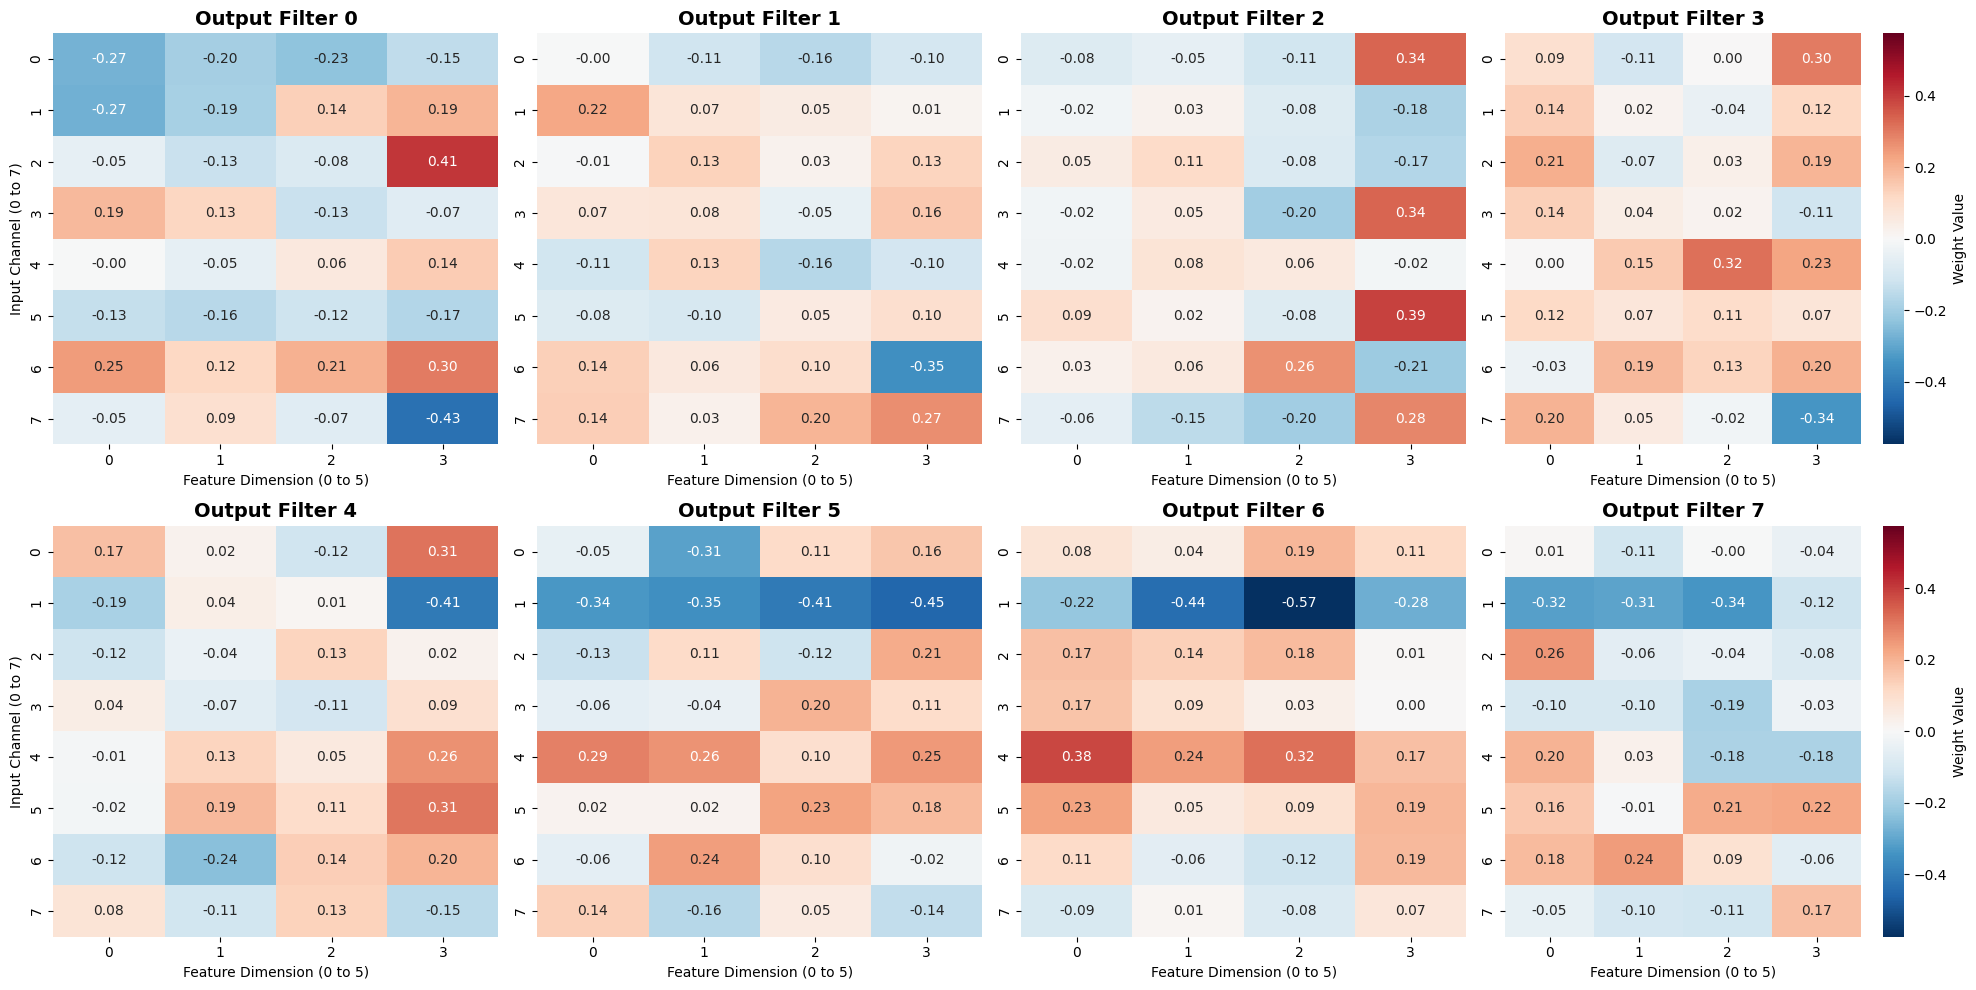

In [29]:
import seaborn as sns
# 假设 feat3_weights 是你从字典里提取出来的 NumPy 数组，形状为 (8, 8, 1, 6)
# squeeze 之后，维度变成 (8, 8, 6) -> (Out_Channels, In_Channels, Features)
weights_3d = feat3_weights.squeeze() 

out_channels, in_channels, num_features = weights_3d.shape

# 创建 2 行 4 列的子图画布 (正好放 8 个 Filter)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# 统一设定热力图的颜色范围 (保证各个子图的颜色刻度具有可比性)
vmax = np.abs(weights_3d).max()
vmin = -vmax

for i in range(out_channels):
    ax = axes[i]
    # 提取第 i 个输出滤波器的权重矩阵，形状为 (8, 6)
    kernel_matrix = weights_3d[i]
    
    # 绘制热力图
    # cmap='RdBu_r'：红色代表正数(看多权重)，蓝色代表负数(看空权重)，白色代表接近 0(无视该特征)
    sns.heatmap(kernel_matrix, ax=ax, cmap='RdBu_r', center=0, 
                vmin=vmin, vmax=vmax, annot=True, fmt=".2f", 
                cbar=(i % 4 == 3), # 只在每行最右边的图显示颜色条
                cbar_kws={'label': 'Weight Value'})
    
    ax.set_title(f'Output Filter {i}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature Dimension (0 to 5)', fontsize=10)
    
    if i % 4 == 0:
        ax.set_ylabel('Input Channel (0 to 7)', fontsize=10)
    else:
        ax.set_ylabel('')

# 调整子图间距
plt.tight_layout()
plt.show()

In [17]:
def validate_engine(model, val_loader, criterion, device):
    model.eval() # Switch to evluation
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad(): # stop gradient
        for data, label in val_loader:
            data, label = data.to(device), label.to(device).long().squeeze()
            all_labels.append(label)

            output = model(data)
            loss = criterion(output, label)
            
            total_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            all_preds.append(predicted)
            total += label.size(0)
            correct += (predicted == label).sum().item()
            
    return total_loss / len(val_loader), 100 * correct / total, all_preds, all_labels   

In [18]:
from sklearn.metrics import classification_report

criterion = nn.CrossEntropyLoss()
avg_val_loss, avg_val_accuracy, preds, labels = validate_engine(test_model, val_loader, criterion= criterion, device=device)

preds = torch.cat(preds, dim = 0).detach().cpu().numpy()
labels = torch.cat(labels, dim = 0).detach().cpu().numpy()

print(f'Validation set Average loss: {avg_val_loss}. Validation set Average accuracy: {avg_val_accuracy}')

print(classification_report(labels, preds, target_names=['Down', 'Stationary', 'Up']))

Validation set Average loss: 1.0743127172933498. Validation set Average accuracy: 42.14524647887324
              precision    recall  f1-score   support

        Down       0.41      0.45      0.43     36800
  Stationary       0.46      0.36      0.40     39752
          Up       0.41      0.46      0.43     37048

    accuracy                           0.42    113600
   macro avg       0.42      0.42      0.42    113600
weighted avg       0.43      0.42      0.42    113600

